# InhibitorCNN — Detection Training

Same model and training loop as `train.ipynb`, but with a different dataset strategy.

**Problem with the original approach:** the model learns *"does the whole image look like a square?"*  
**New approach:** train on composite images — a background doodle with a square or triangle pasted inside it — so the model learns *"is a square/triangle present anywhere?"*

| Class | Label | Training data |
|-------|-------|---------------|
| 0 | **Selective** | random background + square inset |
| 1 | **Toxic** | random background + triangle inset |
| 2 | **Inactive** | random background only |

## Config

In [1]:
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from PIL import Image

from model import InhibitorCNN

DATA_DIR = Path.cwd() / 'data'
CKPT_DIR = Path.cwd() / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLES_PER_CLASS = 10_000
BATCH_SIZE        = 128
EPOCHS            = 25
LR                = 1e-3
WEIGHT_DECAY      = 1e-4
NUM_WORKERS       = 4

BACKGROUND_CATEGORIES = ['circle', 'star', 'zigzag', 'line', 'cloud', 'hexagon']
CLASS_NAMES = ['Selective (square present)', 'Toxic (triangle present)', 'Inactive']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## Dataset

For each positive sample we take a random background doodle and paste a small square or triangle onto it at a random position and scale. The model must find the shape, not recognise the whole image.

In [2]:
import torchvision.transforms as T


class GaussianNoise:
    def __init__(self, std=0.05):
        self.std = std
    def __call__(self, t):
        return (t + torch.randn_like(t) * self.std).clamp(0.0, 1.0)


def build_transforms(augment: bool):
    ops = []
    if augment:
        ops += [
            T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.85, 1.15)),
            T.RandomPerspective(distortion_scale=0.3, p=0.5),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
            GaussianNoise(std=0.04),
        ]
    return T.Compose(ops) if ops else None


def paste_shape(background: np.ndarray, shape: np.ndarray, rng, min_size=6, max_size=26):
    """Paste a resized shape onto a background using max-blend. Both are (28,28) uint8."""
    size = int(rng.integers(min_size, max_size + 1))
    fg   = np.array(Image.fromarray(shape).resize((size, size), Image.NEAREST))
    x    = int(rng.integers(0, 28 - size + 1))
    y    = int(rng.integers(0, 28 - size + 1))
    out  = background.copy()
    out[y:y+size, x:x+size] = np.maximum(out[y:y+size, x:x+size], fg)
    return out


# Fraction of each positive class that are clean QuickDraw samples (no compositing)
CLEAN_FRACTION = 0.25


class DetectionDataset(Dataset):
    def __init__(self, data_dir, split='train', train_ratio=0.85,
                 samples_per_class=SAMPLES_PER_CLASS, seed=42):
        data_dir = Path(data_dir)
        rng = np.random.default_rng(seed)

        squares   = np.load(data_dir / 'square.npy')
        triangles = np.load(data_dir / 'triangle.npy')
        bg_parts  = [np.load(data_dir / f'{c}.npy') for c in BACKGROUND_CATEGORIES]
        backgrounds = np.concatenate(bg_parts, axis=0)
        blank = np.zeros((28, 28), dtype=np.uint8)

        images, labels = [], []

        for fg_pool, label in [(squares, 0), (triangles, 1)]:
            n_clean    = int(samples_per_class * CLEAN_FRACTION)
            n_composite = samples_per_class - n_clean

            # Clean QuickDraw samples — shape fills the canvas as drawn
            clean_idx = rng.choice(len(fg_pool), n_clean, replace=False)
            images.extend(fg_pool[clean_idx].tolist())
            labels.extend([label] * n_clean)

            # Composite samples — shape pasted at random size/position
            for _ in range(n_composite):
                fg = fg_pool[rng.integers(len(fg_pool))].reshape(28, 28)
                bg = backgrounds[rng.integers(len(backgrounds))].reshape(28, 28) \
                     if rng.random() < 0.5 else blank.copy()
                images.append(paste_shape(bg, fg, rng).flatten())
            labels.extend([label] * n_composite)

        # Class 2: background doodles only, no square/triangle
        idx = rng.choice(len(backgrounds), samples_per_class, replace=False)
        images.extend(backgrounds[idx].tolist())
        labels.extend([2] * samples_per_class)

        images = np.array(images, dtype=np.uint8)
        labels = np.array(labels, dtype=np.int64)

        perm = rng.permutation(len(labels))
        images, labels = images[perm], labels[perm]

        n_train = int(len(labels) * train_ratio)
        if split == 'train':
            self.images, self.labels = images[:n_train], labels[:n_train]
        else:
            self.images, self.labels = images[n_train:], labels[n_train:]

        self.transforms = build_transforms(augment=(split == 'train'))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img    = self.images[idx].reshape(28, 28).astype(np.float32) / 255.0
        tensor = torch.from_numpy(img).unsqueeze(0)
        if self.transforms:
            tensor = self.transforms(tensor)
        return tensor, self.labels[idx]


print('Building datasets...')
train_ds = DetectionDataset(DATA_DIR, split='train', samples_per_class=SAMPLES_PER_CLASS)
val_ds   = DetectionDataset(DATA_DIR, split='val',   samples_per_class=SAMPLES_PER_CLASS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

n_clean = int(SAMPLES_PER_CLASS * CLEAN_FRACTION)
print(f'Train: {len(train_ds):,}  |  Val: {len(val_ds):,}')
print(f'Per positive class: {n_clean} clean + {SAMPLES_PER_CLASS - n_clean} composite')

Building datasets...
Train: 25,500  |  Val: 4,500
Per positive class: 2500 clean + 7500 composite


## Visualise samples

Check that the compositing looks right before training.

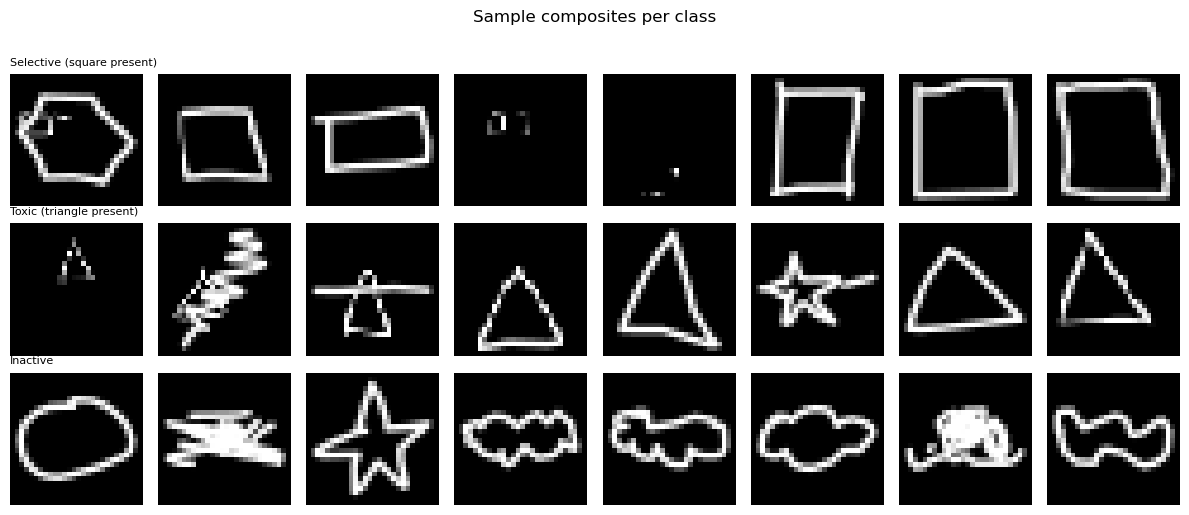

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for cls in range(3):
    idx = np.where(train_ds.labels == cls)[0][:8]
    for col, i in enumerate(idx):
        axes[cls, col].imshow(train_ds.images[i].reshape(28, 28), cmap='gray')
        axes[cls, col].axis('off')
        if col == 0:
            axes[cls, col].set_title(CLASS_NAMES[cls], loc='left', fontsize=8)
plt.suptitle('Sample composites per class', y=1.02)
plt.tight_layout()
plt.show()

## Model

Same InhibitorCNN as before — no architecture change needed.

In [4]:
model = InhibitorCNN(num_classes=3).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 389,059


## Training

In [5]:
def accuracy(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()


def run_epoch(model, loader, criterion, optimizer, train: bool):
    model.train(train)
    total_loss, total_acc, n = 0.0, 0.0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            bs = len(labels)
            total_loss += loss.item() * bs
            total_acc  += accuracy(logits, labels) * bs
            n += bs
    return total_loss / n, total_acc / n


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in tqdm(range(1, EPOCHS + 1), desc='Epochs'):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion, optimizer, train=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    flag = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CKPT_DIR / 'best_model_detection.pt')
        flag = '  <- best'

    print(f'Epoch {epoch:>2}/{EPOCHS} | '
          f'train loss {train_loss:.4f} acc {train_acc:.3f} | '
          f'val loss {val_loss:.4f} acc {val_acc:.3f}{flag}')

print(f'\nBest val accuracy: {best_val_acc:.3f}')
print(f'Checkpoint: {CKPT_DIR / "best_model_detection.pt"}')

Epochs:   4%|▍         | 1/25 [00:21<08:27, 21.16s/it]

Epoch  1/25 | train loss 0.6281 acc 0.730 | val loss 0.6840 acc 0.778  <- best


Epochs:   8%|▊         | 2/25 [00:39<07:29, 19.55s/it]

Epoch  2/25 | train loss 0.4729 acc 0.813 | val loss 0.4763 acc 0.855  <- best


Epochs:  12%|█▏        | 3/25 [00:57<06:56, 18.93s/it]

...

Epoch  8/25 | train loss 0.3520 acc 0.866 | val loss 0.3376 acc 0.902


Epochs:  36%|███▌      | 9/25 [02:47<04:53, 18.32s/it]

Epoch  9/25 | train loss 0.3376 acc 0.874 | val loss 0.2278 acc 0.930  <- best


Epochs:  36%|███▌      | 9/25 [02:53<05:08, 19.26s/it]


KeyboardInterrupt: 

## Results

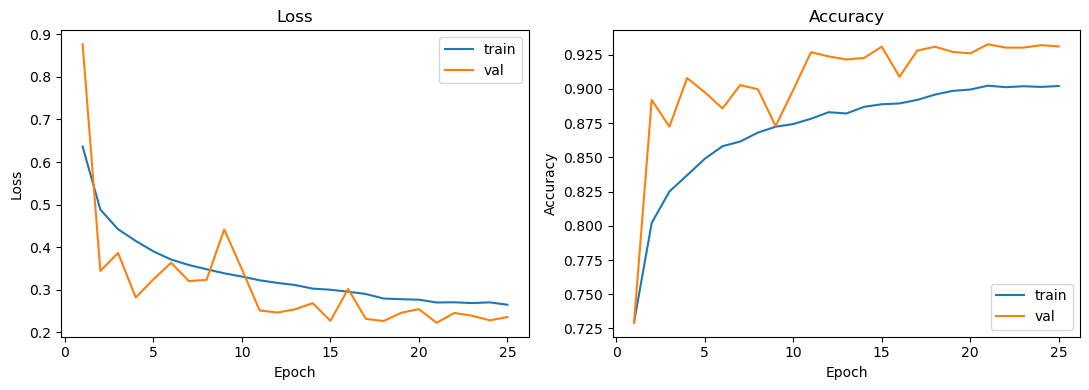

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
epochs = range(1, EPOCHS + 1)
ax1.plot(epochs, history['train_loss'], label='train')
ax1.plot(epochs, history['val_loss'],   label='val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss'); ax1.legend()
ax2.plot(epochs, history['train_acc'], label='train')
ax2.plot(epochs, history['val_acc'],   label='val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy'); ax2.legend()
plt.tight_layout()
plt.show()

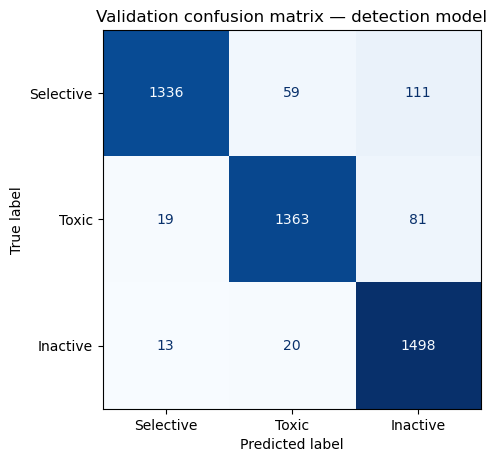

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.load_state_dict(torch.load(CKPT_DIR / 'best_model_detection.pt', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs.to(device)).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Selective', 'Toxic', 'Inactive'])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Validation confusion matrix — detection model')
plt.tight_layout()
plt.show()